# Step 1: Setup Dependencies

In [1]:
!pip install torch torchvision faiss-cpu transformers pillow 
!pip install open_clip_torch==2.23.0
!pip install --upgrade pip
!pip install transformers accelerate sentencepiece einops
!pip install -U bitsandbytes

# Step 2: Embedding data and store in FAISS



In [2]:
# =========================================================
# Setup environment and paths (User Provided)
# =========================================================
import os, json, torch, faiss, gc
import numpy as np
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
import torch.nn.functional as F
from IPython.display import display, Image as IPImage

# User paths - CORRECTED
BASE_DIR = Path("/kaggle/input/extracted-clinical-dataset")
JSON_DIR = BASE_DIR / "extracted_json"
IMG_DIR = BASE_DIR / "extracted_images"  
TABLE_DIR = BASE_DIR / "extracted_tables"
OUTPUT_DIR = Path("/kaggle/working/output")
FAISS_INDEX_PATH = OUTPUT_DIR / "clinicalcasesDB_index.faiss"
METADATA_PATH = OUTPUT_DIR / "clinicalcasesDB_metadata.json"

# Create output dir if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


2026-01-26 17:47:38.868738: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769449658.891577     519 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769449658.898561     519 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769449658.916543     519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769449658.916575     519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769449658.916578     519 computation_placer.cc:177] computation placer alr

Device: cuda


In [3]:
# =========================================================
# 📚 Load models: BioClinicalBERT (text) + CLIP (text+image)
# =========================================================
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
from PIL import Image
import torch

# 1. BioClinicalBERT model
bio_model_name = "emilyalsentzer/Bio_ClinicalBERT"
bio_tokenizer = AutoTokenizer.from_pretrained(bio_model_name)
bio_model = AutoModel.from_pretrained(bio_model_name).to(device)
bio_model.eval()

# 2. CLIP for image
clip_model_name = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_model.eval()

# dimensions
bio_dim = 768  # BioClinicalBERT embedding size
clip_text_dim = clip_model.text_model.final_layer_norm.normalized_shape[0]
clip_image_dim = clip_model.visual_projection.out_features

print("Dimensions:")
print(f"  BioClinicalBERT text dim: {bio_dim}")
print(f"  CLIP text dim: {clip_text_dim}")
print(f"  CLIP image dim: {clip_image_dim}")

final_dim = bio_dim + clip_text_dim + clip_image_dim
print("Final fused embedding dimension:", final_dim)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Dimensions:
  BioClinicalBERT text dim: 768
  CLIP text dim: 512
  CLIP image dim: 512
Final fused embedding dimension: 1792


In [4]:
# ---------------------------------------------------------
# BioClinicalBERT embedding
# ---------------------------------------------------------
def embed_bio_text(text: str, mode: str = "general"):
    """
    BioClinicalBERT mean-pooled embedding with optional diagnostic emphasis.
    mode ∈ {"general", "diagnosis", "management"}
    """
    if not text or not text.strip():
        return np.zeros((1, bio_model.config.hidden_size), dtype="float32")

    toks = bio_tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        out = bio_model(**toks)
        hidden = out.last_hidden_state  # (B, L, H)

        # 🩺 Section-specific pooling weights
        if mode == "diagnosis":
            # CLS token carries summary semantics, add more weight to it
            emb = 0.7 * hidden[:, 0, :] + 0.3 * hidden.mean(dim=1)
        elif mode == "management":
            # Use average pooling, but emphasize later tokens (often actions)
            seq_weights = torch.linspace(0.5, 1.0, hidden.shape[1], device=hidden.device)
            emb = (hidden * seq_weights.unsqueeze(0).unsqueeze(-1)).mean(dim=1)
        else:
            # generic mean pooling
            emb = hidden.mean(dim=1)

        emb = F.normalize(emb, dim=-1)

    return emb.cpu().numpy().astype("float32")  # (1, bio_dim)


# ---------------------------------------------------------
# CLIP Text embedding
# ---------------------------------------------------------
def embed_clip_text(text: str):
    """
    CLIP text encoder → (1 x clip_text_dim)
    Handles long text by chunking (CLIP performs best on <77 tokens).
    """
    if not text or not text.strip():
        return np.zeros((1, clip_model.text_projection.shape[1]), dtype="float32")

    # Split long text to chunks for CLIP (optional but helpful)
    chunks = [text[i:i + 300] for i in range(0, len(text), 300)]
    embs = []
    for chunk in chunks:
        inputs = clip_processor(text=[chunk], return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            e = clip_model.get_text_features(**inputs)
            e = F.normalize(e, dim=-1)
        embs.append(e.cpu().numpy())
    emb = np.mean(np.vstack(embs), axis=0, keepdims=True)
    emb /= max(np.linalg.norm(emb), 1e-6)
    return emb.astype("float32")


# ---------------------------------------------------------
# CLIP Image embedding
# ---------------------------------------------------------
def embed_clip_image_path(img_path: Path):
    """
    CLIP image encoder → (1 x clip_image_dim)
    Returns zeros if missing or failed.
    """
    if not img_path or not Path(img_path).exists():
        return np.zeros((1, clip_image_dim), dtype="float32")

    try:
        pil = Image.open(img_path).convert("RGB")
        inputs = clip_processor(images=pil, return_tensors="pt").to(device)
        with torch.no_grad():
            emb = clip_model.get_image_features(**inputs)
            emb = F.normalize(emb, dim=-1)
        return emb.cpu().numpy().astype("float32")
    except Exception as e:
        print(f"⚠️ Image embed error {img_path}: {e}")
        return np.zeros((1, clip_image_dim), dtype="float32")

def get_fused_text_embedding(text):
    """
    Fuse BioClinicalBERT + CLIP text + dummy CLIP image to match FAISS index dimension (1792).
    This version matches the OLD working implementation but with proper truncation fixes.
    """
    if not text or not text.strip():
        return np.zeros((1, final_dim), dtype="float32")
    
    # --- 1. BioClinicalBERT text embedding (768) ---
    bio_inputs = bio_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        bio_out = bio_model(**bio_inputs).last_hidden_state.mean(dim=1)

    # --- 2. CLIP text embedding (512) ---
    # CRITICAL FIX: Add proper truncation to prevent ValueError
    clip_inputs = clip_processor(
        text=[text], 
        images=None, 
        return_tensors="pt", 
        padding=True,
        max_length=77,       # CLIP's max token limit
        truncation=True      # Enable truncation
    ).to(device)
    
    with torch.no_grad():
        clip_text_features = clip_model.get_text_features(**clip_inputs)

    # --- 3. Dummy CLIP image embedding (512) ---
    clip_img_dim = clip_model.visual_projection.out_features  # should be 512
    clip_image_features = torch.zeros((1, clip_img_dim), device=device)

    # --- 4. Concatenate all three parts (SAME AS OLD CODE) ---
    # NO weighted fusion to match the old working version
    fused = torch.cat([bio_out, clip_text_features, clip_image_features], dim=1).squeeze(0)
    
    # --- 5. Normalize (SAME AS OLD CODE) ---
    fused = fused / fused.norm(dim=0, keepdim=True)
    
    # Return as 2D numpy array for FAISS compatibility
    return fused.cpu().numpy().astype("float32").reshape(1, -1)

In [5]:
# =========================================================
# Build weighted fused vectors with structured metadata
# =========================================================
json_files = list(JSON_DIR.glob("*.json"))
print("Files detected:", len(json_files))

if not json_files:
    raise FileNotFoundError(f"No JSON files found in {JSON_DIR}. Please check your path.")

all_vectors = []
metadata = []

# Section weighting scheme (diagnosis emphasis)
section_weights = {
    "final_diagnosis": 3.0,
    "differential_diagnosis": 2.0,
    "management_and_clinical_course": 2.0,
    "labs_and_diagnostics": 1.2,
    "history_of_present_illness": 3.0,
    "physical_exam": 2.0,
    "exposure_and_epidemiology": 3.0,
    "vitals": 0.5,
    "patient_information": 0.5,
    "chief_complaint": 2.0,
}

for jpath in tqdm(json_files, desc="Embedding cases"):
    with open(jpath, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Structured metadata text
    full_text = " ".join(
        f"{key.replace('_',' ').title()}: {data.get(key, '')}."
        for key in section_weights.keys()
        if data.get(key)
    )

    # Section-wise BioClinicalBERT embeddings
    section_embs = []
    total_weight = 0.0

    for key, weight in section_weights.items():
        value = data.get(key, "")
        if not value:
            continue

        # Diagnostic-aware modes
        if key in ["final_diagnosis", "differential_diagnosis"]:
            emb = embed_bio_text(value, mode="diagnosis")
        elif key in ["management_and_clinical_course"]:
            emb = embed_bio_text(value, mode="management")
        else:
            emb = embed_bio_text(value, mode="general")

        emb /= max(np.linalg.norm(emb), 1e-6)
        section_embs.append(weight * emb)
        total_weight += weight

    # Weighted average BioClinicalBERT vector
    if section_embs:
        bio_emb = np.sum(section_embs, axis=0) / total_weight
    else:
        bio_emb = embed_bio_text(full_text, mode="general")

    # CLIP text embedding
    clip_text_emb = embed_clip_text(full_text)
    clip_text_emb /= max(np.linalg.norm(clip_text_emb), 1e-6)

    # CLIP image embeddings
    clip_image_emb = np.zeros((1, clip_image_dim), dtype="float32")
    images = data.get("images", [])
    if images:
        try:
            image_embs = [
                embed_clip_image_path(IMG_DIR / (img.get("file_name", img)))
                for img in images
            ]
            clip_image_emb = np.mean(np.vstack(image_embs), axis=0, keepdims=True)
            clip_image_emb /= max(np.linalg.norm(clip_image_emb), 1e-6)
        except Exception as e:
            print(f"⚠️ Image embedding failed for {jpath}: {e}")

    # Weighted multimodal fusion
    fused = np.hstack([
        2.0 * bio_emb,         # core semantics
        0.75 * clip_text_emb,  # text coherence
        0.25 * clip_image_emb  # visual info
    ])
    fused /= max(np.linalg.norm(fused), 1e-6)

    # Collect
    all_vectors.append(fused[0])
    metadata.append({
        "file": str(jpath),
        "text": full_text,
        "images": images,
    })

# =========================================================
# Build FAISS index
# =========================================================
if not all_vectors:
    raise RuntimeError("No embeddings were generated. Check your embedding functions or JSON content.")

all_vecs = np.vstack(all_vectors).astype("float32")
print("Final vector matrix shape:", all_vecs.shape)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

index = faiss.IndexFlatIP(all_vecs.shape[1])  # cosine similarity via inner product
index.add(all_vecs)
faiss.write_index(index, str(FAISS_INDEX_PATH))
print("✅ FAISS index saved to:", FAISS_INDEX_PATH)

Files detected: 93


Embedding cases: 100%|██████████| 93/93 [00:20<00:00,  4.64it/s]

Final vector matrix shape: (93, 1792)
✅ FAISS index saved to: /kaggle/working/output/clinicalcasesDB_index.faiss


# Step 3: Retrieve Data from FAISS 


In [6]:
!pip install sentence-transformers

import torch
from sentence_transformers import CrossEncoder
import numpy as np
from typing import List, Dict, Tuple

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def get_multimodal_query_embedding(query_text, query_image=None):
    """
    Generate multimodal query embedding with dynamic fusion weights.
    Uses different weights based on whether image is present:
    - With image: [1.85, 0.75, 0.4] for [bio, clip_text, clip_image]  
    - Without image: [2.0, 0.75, 0.25] for [bio, clip_text, clip_image]
    """
    if not query_text or not query_text.strip():
        return np.zeros((1, final_dim), dtype="float32")
    
    # --- 1. BioClinicalBERT text embedding (768) ---
    bio_inputs = bio_tokenizer(query_text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        bio_out = bio_model(**bio_inputs).last_hidden_state.mean(dim=1)

    # --- 2. CLIP text embedding (512) ---
    clip_inputs = clip_processor(
        text=[query_text], 
        images=None, 
        return_tensors="pt", 
        padding=True,
        max_length=77,       
        truncation=True      
    ).to(device)
    
    with torch.no_grad():
        clip_text_features = clip_model.get_text_features(**clip_inputs)

    # --- 3. CLIP image embedding (512) ---
    if query_image is not None:
        try:
            clip_inputs_img = clip_processor(
                text=None,
                images=query_image,
                return_tensors="pt"
            ).to(device)
            with torch.no_grad():
                clip_image_features = clip_model.get_image_features(**clip_inputs_img)
        except Exception as e:
            print(f"Image processing failed: {e}")
            clip_image_features = torch.zeros((1, clip_image_dim), device=device)
    else:
        clip_image_features = torch.zeros((1, clip_image_dim), device=device)

    # --- 4. Dynamic fusion weights based on image presence ---
    if query_image is not None:
        # Multimodal with image: reduce bio weight, increase image weight
        fusion_weights = [1.85, 0.75, 0.4]
    else:
        # Text-only: standard weights (same as get_fused_text_embedding)
        fusion_weights = [2.0, 0.75, 0.25]
    
    # --- 5. Apply weighted fusion ---
    fused = torch.cat([
        fusion_weights[0] * bio_out,
        fusion_weights[1] * clip_text_features, 
        fusion_weights[2] * clip_image_features
    ], dim=1).squeeze(0)
    
    # --- 6. Normalize ---
    fused = fused / fused.norm(dim=0, keepdim=True)
    
    return fused.cpu().numpy().astype("float32").reshape(1, -1)

def rerank_passages(query: str, passages: List[Dict], top_k: int = 5, alpha: float = 0.7) -> List[Dict]:
    """Re-rank retrieved passages using cross-encoder scores."""
    if not cross_encoder or not passages:
        return passages[:top_k]
    
    # Prepare query-passage pairs for cross-encoder
    query_passage_pairs = []
    for passage in passages:
        passage_text = passage.get('text', '')[:1000]
        query_passage_pairs.append([query, passage_text])
    
    # Get cross-encoder relevance scores
    try:
        ce_scores = cross_encoder.predict(query_passage_pairs)
    except Exception as e:
        return passages[:top_k]
    
    # Combine with original embedding similarities
    reranked_passages = []
    for i, passage in enumerate(passages):
        original_score = passage.get('similarity_score', 0.5)
        combined_score = alpha * original_score + (1 - alpha) * float(ce_scores[i])
        
        updated_passage = passage.copy()
        updated_passage['rerank_score'] = float(ce_scores[i])
        updated_passage['combined_score'] = combined_score
        updated_passage['original_score'] = original_score
        
        reranked_passages.append(updated_passage)
    
    # Sort by combined score (highest first)
    reranked_passages.sort(key=lambda x: x['combined_score'], reverse=True)
    return reranked_passages[:top_k]

def retrieve_and_rerank_context(query: str, top_k_initial: int = 10, top_k_final: int = 3):
    """Enhanced retrieval pipeline with re-ranking (text-only)."""
    # Step 1: Initial retrieval with embedding similarity
    query_emb = get_fused_text_embedding(query).reshape(1, -1)
    scores, indices = index.search(query_emb, top_k_initial)
    
    # Build initial passage list with similarity scores
    initial_passages = []
    for idx, score in zip(indices[0], scores[0]):
        entry = metadata[idx]
        passage = {
            'text': entry.get('text', ''),
            'file': entry.get('file', ''),
            'images': entry.get('images', []),
            'similarity_score': float(score),
            'index': int(idx),
            'retrieval_type': 'text-only'
        }
        initial_passages.append(passage)
    
    # Step 2: Re-rank using cross-encoder
    final_passages = rerank_passages(query, initial_passages, top_k_final)
    return final_passages

def retrieve_context_with_images_reranked(query: str, query_image=None, top_k_initial: int = 10, top_k_final: int = 3):
    """Enhanced version with TRUE multimodal retrieval when image is present."""
    
    # Step 1: Use multimodal embedding for initial retrieval
    if query_image is not None:
        query_emb = get_multimodal_query_embedding(query, query_image).reshape(1, -1)
        retrieval_type = 'multimodal'
    else:
        query_emb = get_fused_text_embedding(query).reshape(1, -1)
        retrieval_type = 'text-only'
    
    scores, indices = index.search(query_emb, top_k_initial)
    
    # Build initial passage list with similarity scores
    initial_passages = []
    for idx, score in zip(indices[0], scores[0]):
        entry = metadata[idx]
        passage = {
            'text': entry.get('text', ''),
            'file': entry.get('file', ''),
            'images': entry.get('images', []),
            'similarity_score': float(score),
            'index': int(idx),
            'retrieval_type': retrieval_type
        }
        initial_passages.append(passage)
    
    # Step 2: Re-rank using cross-encoder
    final_passages = rerank_passages(query, initial_passages, top_k_final)
    
    # Step 3: Load images for final passages
    results = []
    for passage in final_passages:
        # Load actual images
        pil_images = []
        captions = []
        for img_info in passage.get('images', []):
            img_path = Path("/kaggle/input/extracted-clinical-dataset") / img_info.get('file_name', '')
            if img_path.exists():
                try:
                    pil_img = Image.open(img_path).convert('RGB')
                    pil_images.append(pil_img)
                    captions.append(img_info.get('caption', 'Medical image'))
                except Exception as e:
                    continue
        
        # Build final result
        result = {
            'text': passage['text'],
            'images': pil_images,
            'captions': captions,
            'file': passage['file'],
            'similarity_score': passage.get('similarity_score', 0),
            'rerank_score': passage.get('rerank_score', 0),
            'combined_score': passage.get('combined_score', 0),
            'retrieval_type': passage.get('retrieval_type', 'unknown')
        }
        results.append(result)
    
    return results

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


#1 — Score=0.869
File:/kaggle/input/extracted-clinical-dataset/extracted_json/66---A-32-Year-Old-Man-from-Malawi-With-Pain-in-the-_2022_Clinical-Cases-in-.json
Final Diagnosis: The final diagnosis is HIV-associated tuberculous pericardial tamponade. This is supported by the clinical presentation of right upper abdominal pain, breathlessness, and syncope, alo...


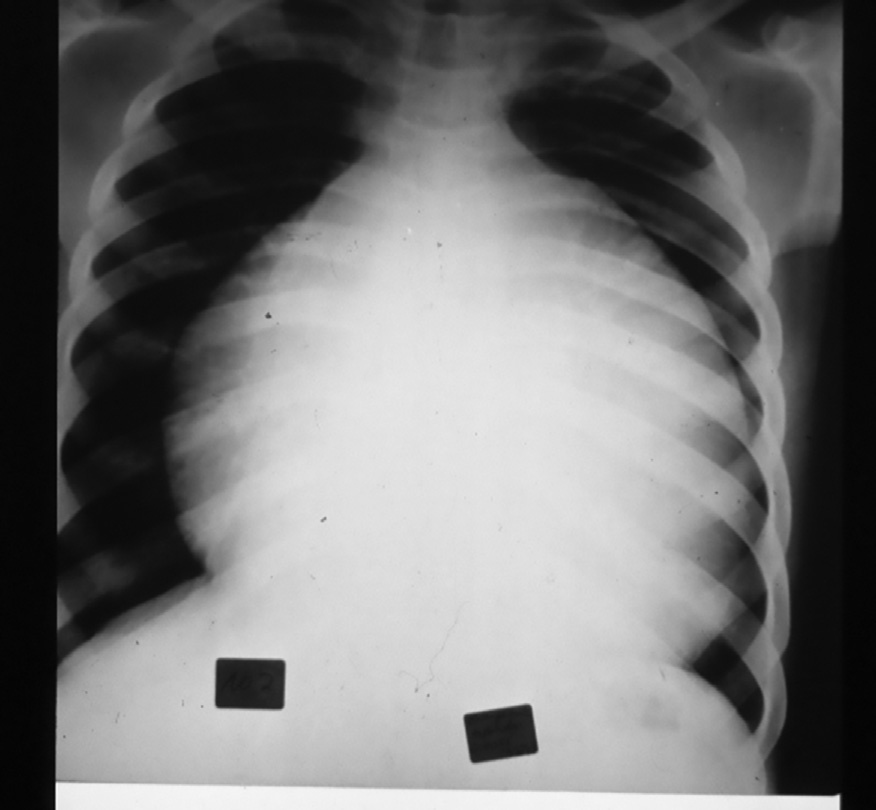

   Chest radiograph of the patient showing an enlarged globular cardiac silhouette with clear lung fields.
------------------------------
#2 — Score=0.867
File:/kaggle/input/extracted-clinical-dataset/extracted_json/63---A-38-Year-Old-European-Expatriate-Living-in-M_2022_Clinical-Cases-in-Tr.json
Final Diagnosis: The final diagnosis was an infection with Schistosoma haematobium, complicated by spinal cord schistosomiasis presenting as a conus syndrome. This was evidenced by the identification ...


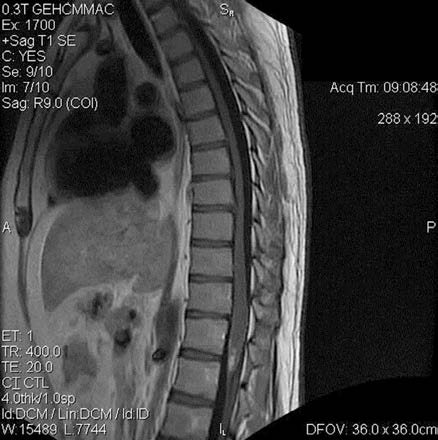

   T2-weighted MRI scan of the spinal cord.
------------------------------
#3 — Score=0.867
File:/kaggle/input/extracted-clinical-dataset/extracted_json/58---A-25-Year-Old-Woman-from-Egypt-With-Severe-Ch_2022_Clinical-Cases-in-Tr.json
Final Diagnosis: The final diagnosis is Intestinal Capillariasis caused by Capillaria philippinensis. This was supported by the patient's clinical presentation of severe chronic diarrhoea and malabsor...
------------------------------


[(np.int64(84),
  np.float32(0.8690555),
  {'file': '/kaggle/input/extracted-clinical-dataset/extracted_json/66---A-32-Year-Old-Man-from-Malawi-With-Pain-in-the-_2022_Clinical-Cases-in-.json',
   'text': "Final Diagnosis: The final diagnosis is HIV-associated tuberculous pericardial tamponade. This is supported by the clinical presentation of right upper abdominal pain, breathlessness, and syncope, along with physical exam findings of cardiac decompensation and a chest radiograph showing an enlarged globular cardiac silhouette. The history of a previous herpes zoster lesion strongly pointed to HIV infection, which was confirmed by a positive HIV test. The rapid improvement after therapeutic pericardial aspiration and a full course of antituberculous treatment, corticosteroids, and antiretroviral therapy further confirms the diagnosis.. Differential Diagnosis: Based on the clinical history, examination, and chest radiograph findings, the most likely pathology is pericardial tamponade ca

In [7]:
# =========================================================
# Clinical Retrieval with Image Display
# =========================================================
def search_with_images(query_text: str, k: int = 5):
    """Search clinical FAISS index and display retrieved images."""
    if not len(metadata):
        return

    # Build text embeddings
    bio_q = embed_bio_text(query_text) if query_text else np.zeros((1, bio_dim), dtype="float32")
    clip_text_q = embed_clip_text(query_text) if query_text else np.zeros((1, clip_text_dim), dtype="float32")

    # Weighted fusion
    clip_img_q = np.zeros((1, clip_image_dim), dtype="float32")
    fused_q = np.hstack([
        2.0 * bio_q,
        0.75 * clip_text_q,
        0.25 * clip_img_q
    ])
    fused_q /= max(np.linalg.norm(fused_q), 1e-6)

    # FAISS search
    D, I = index.search(fused_q, k)

    # Display results
    results = []
    for rank, (idx, emb_score) in enumerate(zip(I[0], D[0]), start=1):
        entry = metadata[idx]
        results.append((idx, emb_score, entry))
        print(f"#{rank} — Score={emb_score:.3f}")
        print(f"File:{entry['file']}")
        print(f"{entry['text'][:200]}...")
        
        # Display images if available
        images = entry.get('images', [])
        if images:
            for img_info in images[:2]:  # Limit to 2 images
                img_path = Path("/kaggle/input/extracted-clinical-dataset") / img_info.get('file_name', '')
                if img_path.exists():
                    try:
                        pil_img = Image.open(img_path)
                        display(pil_img)
                        caption = img_info.get('caption', 'No caption')
                        print(f"   {caption}")
                    except Exception as e:
                        continue
        print("-"*30)

    return results

# =========================================================
# Example Retrieval
# =========================================================
search_with_images("A man breathless in the supine position with pulsus paradoxus", k=3)

# Step 4: Baseline Model and Variants Setup



In [8]:
# =========================================================
# Load Llava-1.6 Baseline Model
# =========================================================
import gc
import torch
from transformers import BitsAndBytesConfig, LlavaProcessor, LlavaForConditionalGeneration

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

# LLaVA model setup
LLAVA_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load processor + model
llava_processor = LlavaProcessor.from_pretrained(LLAVA_ID)
llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    torch_dtype=torch.float16
)
llava_model.eval()

Device: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
You are using a model of type llava_next to instantiate a model of type llava. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affi

In [9]:
# =========================================================
# Four Generation Variants
# =========================================================
import json, re, gc, faiss, torch, time
from pathlib import Path
from PIL import Image
from transformers import (
    AutoProcessor, AutoModel,
    LlavaProcessor, LlavaForConditionalGeneration,
    BitsAndBytesConfig
)

# Paths (use the same base as embedding step)
BASE_DATA = Path("/kaggle/input/extracted-clinical-dataset")
JSON_DIR = BASE_DATA / "extracted_json"
IMG_DIR = BASE_DATA / "extracted_images"

RAG_OUTPUT_DIR = Path("/kaggle/working/output")
FAISS_INDEX_PATH = RAG_OUTPUT_DIR / "medclip_index.faiss"
METADATA_PATH = RAG_OUTPUT_DIR / "medclip_metadata.json"

# Load FAISS + metadata
index = faiss.read_index(str(FAISS_INDEX_PATH))
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)
print(f"FAISS loaded: {index.ntotal} cases")

def get_text_embedding(text):
    """Compute BioClinicalBERT embedding for retrieval."""
    inputs = bio_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = bio_model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding / np.linalg.norm(embedding)

# =========================================================
# VARIANT 1a: Model + Text-only (No RAG, No Image)
# =========================================================

def generate_answer_model_only(question, max_new_tokens=256, temperature=0.7):
    """Variant 1a: Pure model generation without RAG retrieval (text-only)."""
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Provide two fields:
- Answer: concise final answer
- Clinical Rationale: brief reasoning (2-4 sentences).

If context is provided, ground your reasoning in it; if not, rely on medical knowledge.

Context:
None provided

Question:
{question}

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(
            text=prompt,
            images=None,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[Model-Only] {answer}"
        
    except Exception as e:
        answer = f"[Model-Only Error] {str(e)}"

    return answer, []

# =========================================================
# VARIANT 1b: Model + Image (No RAG, With Image)
# =========================================================

def generate_answer_model_only_multimodal(question, query_image=None, max_new_tokens=256, temperature=0.7):
    """Variant 1b: Pure model generation with image input (no RAG retrieval)."""
    
    prompt = f"""<|user|>:
<image>
You are a medical AI assistant. Provide two fields:
- Answer: concise final answer
- Clinical Rationale: brief reasoning (2-4 sentences).

Analyze the medical image and ground your reasoning in the visual findings and medical knowledge.

Question:
{question}

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(
            images=[query_image],
            text=prompt,
            return_tensors="pt"
        ).to(device)
        
        if 'image_sizes' in inputs:
            del inputs['image_sizes']
        
        if 'pixel_values' in inputs:
            if inputs['pixel_values'].dim() == 5:
                inputs['pixel_values'] = inputs['pixel_values'][:, 0, :, :, :]
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[Model-Only-Multimodal] {answer}"
        
    except Exception as e:
        print(f"⚠️ Model-Only-Multimodal Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, []

    return answer, []

# =========================================================
# VARIANT 2: Model + RAG + Text-only (With Re-ranking)
# =========================================================

def generate_answer_rag_text_only(question, top_k_initial=10, top_k_final=5, max_new_tokens=256, temperature=0.7):
    """Variant 2: RAG-enhanced generation with re-ranking (text-only)."""
    
    retrieved_docs = retrieve_and_rerank_context(question, top_k_initial, top_k_final)
    
    context_texts = []
    for i, doc in enumerate(retrieved_docs):
        score_info = f"[Relevance: {doc.get('combined_score', 0):.3f}]"
        retrieval_info = f"[{doc.get('retrieval_type', 'unknown')}]"
        context_text = f"[Case {i+1}] {retrieval_info} {score_info} {doc['text'][:500]}..."
        context_texts.append(context_text)
    
    context = "\n\n".join(context_texts)
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Provide two fields:
- Answer: concise final answer
- Clinical Rationale: brief reasoning (2-4 sentences).

Context:
{context}

Question:
{question}

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(
            text=prompt,
            images=None,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[RAG+Text-only] {answer}"
        
    except Exception as e:
        answer = f"[RAG+Text-only Error] {str(e)}"

    return answer, retrieved_docs

# =========================================================
# VARIANT 3: Model + RAG + Multimodal (With Enhanced Re-ranking)
# =========================================================

def generate_answer_rag_multimodal(question, query_image=None, top_k_initial=10, top_k_final=5, max_new_tokens=256, temperature=0.7):
    """Variant 3: Full multimodal RAG with enhanced re-ranking and images."""
    
    if query_image is None:
        return None, []
    
    retrieved_docs = retrieve_context_with_images_reranked(
        query=question, 
        query_image=query_image,
        top_k_initial=top_k_initial, 
        top_k_final=top_k_final
    )
    
    context_texts = []
    for i, doc in enumerate(retrieved_docs):
        score_info = f"[Relevance: {doc.get('combined_score', 0):.3f}]"
        image_info = f"[Images: {len(doc['images'])}]" if doc['images'] else "[No images]"
        retrieval_info = f"[{doc.get('retrieval_type', 'unknown')}]"
        context_text = f"[Case {i+1}] {retrieval_info} {score_info} {image_info} {doc['text'][:400]}..."
        context_texts.append(context_text)
    
    context = "\n\n".join(context_texts)
    
    prompt = f"""<|user|>:
<image>
You are a medical AI assistant. Provide two fields:
- Answer: concise final answer
- Clinical Rationale: brief reasoning (2-4 sentences).

Medical images are available for visual analysis.

Context:
{context}

Question:
{question}

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(
            images=[query_image],
            text=prompt,
            return_tensors="pt"
        ).to(device)
        
        if 'image_sizes' in inputs:
            del inputs['image_sizes']
        
        if 'pixel_values' in inputs:
            if inputs['pixel_values'].dim() == 5:
                inputs['pixel_values'] = inputs['pixel_values'][:, 0, :, :, :]
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[RAG+Multimodal] {answer}"
        
    except Exception as e:
        print(f"⚠️ RAG+Multimodal Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, []
    
    return answer, retrieved_docs

# =========================================================
# Generation Pipeline with 4 variants
# =========================================================

def generate_all_variants(question, query_image=None, top_k_initial=10, top_k_final=5):
    """Generate answers using all four variants for comparison."""
    
    results = {}
    print(f"\n PROCESSING QUESTION: {question[:100]}...")
    print(f" Query image provided: {'Yes' if query_image is not None else 'No'}")
    print("="*50)
    
    # Variant 1a: Model-only (text)
    try:
        answer1, docs1 = generate_answer_model_only(question)
        results['model_only'] = {'answer': answer1, 'docs': docs1}
    except Exception as e:
        print(f"⚠️ Variant 1a Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        results['model_only'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 1b: Model-only (multimodal) - only if image provided
    if query_image is not None:
        try:
            answer1b, docs1b = generate_answer_model_only_multimodal(question, query_image)
            results['model_only_multimodal'] = {'answer': answer1b, 'docs': docs1b}
        except Exception as e:
            print(f"⚠️ Variant 1b Error: {type(e).__name__}: {str(e)}")
            import traceback
            traceback.print_exc()
            results['model_only_multimodal'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 2: RAG + Text-only
    try:
        answer2, docs2 = generate_answer_rag_text_only(question, top_k_initial, top_k_final)
        results['rag_text'] = {'answer': answer2, 'docs': docs2}
    except Exception as e:
        print(f"⚠️ Variant 2 Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        results['rag_text'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 3: RAG + Multimodal
    try:
        answer3, docs3 = generate_answer_rag_multimodal(question, query_image, top_k_initial, top_k_final)
        results['rag_multimodal'] = {'answer': answer3, 'docs': docs3}
    except Exception as e:
        print(f"⚠️ Variant 3 Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        results['rag_multimodal'] = {'answer': f"Error: {e}", 'docs': []}

        return results
    return results

FAISS loaded: 93 cases


In [10]:
# # =========================================
# # Testing All Four Generation Variants - No image
# # =========================================

# # Case 70: Scrub typhus (no images)
# case_question = (
#     "A 58-year-old rural woman from Sri Lanka presents with a 5-day progressive illness starting with high fever, "
#     "headache, and myalgia. History reveals she works in rice fields with recent exposure to scrubland vegetation. "
#     "On day 2, she developed neurological symptoms including confusion, hearing loss, coarse tremors, and saccadic eye movements. "
#     "Physical exam shows hepatosplenomegaly, enlarged axillary lymph nodes, and a pathognomonic crater-like eschar in the right axilla. "
#     "Laboratory findings include normal WBC count, thrombocytopenia, and elevated liver enzymes. CSF analysis shows lymphocytic pleocytosis. "
#     "Given the endemic area for trombiculid mite-transmitted disease and clinical presentation with eschar, "
#     "what is the final diagnosis?"
# )

# print(f"🩺 Test Question (Case 70 - Scrub Typhus): {case_question[:100]}...")
# print("="*70)

# # Generate all variants (no image - should produce 3 variants)
# all_results = generate_all_variants(
#     question=case_question,
#     query_image=None,  # NO IMAGE
#     top_k_initial=8,
#     top_k_final=5
# )

# # Display concise results
# print("\n RESULTS (No Image - 3 Variants):")
# print("="*70)

# print("\n VARIANT 1a: Model + Text-only")
# if all_results.get('model_only') and all_results['model_only'].get('answer') is not None:
#     print(all_results['model_only']['answer'][:200] + "...")
# else:
#     print("⚠️ Generation failed")

# print("\n VARIANT 1b: Model + Multimodal (Image)")
# if all_results.get('model_only_multimodal') and all_results['model_only_multimodal'].get('answer') is not None:
#     print(all_results['model_only_multimodal']['answer'][:200] + "...")
# else:
#     print("⚠️ Skipped (no image provided)")

# print("\n VARIANT 2: Model + RAG + Text-only")
# if all_results.get('rag_text') and all_results['rag_text'].get('answer') is not None:
#     print(all_results['rag_text']['answer'][:200] + "...")
# else:
#     print("⚠️ Generation failed")
# if all_results['rag_text']['docs']:
#     print(f"\n Text-Only Re-ranked Contexts ({len(all_results['rag_text']['docs'])}):")
#     for i, doc in enumerate(all_results['rag_text']['docs'], 1):
#         combined_score = doc.get('combined_score', 0)
#         original_score = doc.get('similarity_score', 0)
#         rerank_score = doc.get('rerank_score', 0)
#         retrieval_type = doc.get('retrieval_type', 'unknown')
#         print(f"  [{i}] Type: {retrieval_type}")
#         print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f}")

# print("\n VARIANT 3: Model + RAG + Multimodal")
# if all_results.get('rag_multimodal') and all_results['rag_multimodal'].get('answer') is not None:
#     print(all_results['rag_multimodal']['answer'][:200] + "...")
#     if all_results['rag_multimodal'].get('docs'):
#         print(f"\n Multimodal Re-ranked Contexts ({len(all_results['rag_multimodal']['docs'])}):")
#         for i, doc in enumerate(all_results['rag_multimodal']['docs'], 1):
#             img_count = len(doc.get('images', []))
#             combined_score = doc.get('combined_score', 0)
#             original_score = doc.get('similarity_score', 0)
#             rerank_score = doc.get('rerank_score', 0)

#             retrieval_type = doc.get('retrieval_type', 'unknown')

#             print(f"  [{i}] Type: {retrieval_type}")
#             print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f} | Images: {img_count}")
# else:
#     print("⚠️ Skipped (no image provided)")

In [11]:
# # =========================================================
# # Testing All Four Generation Variants - Has image input
# # =========================================================

# # Load query image from Fasciola hepatica case (Case 67)
# query_image_path = Path("/kaggle/input/extracted-clinical-dataset/extracted_images/67---A-24-Year-Old-Woman-from-the-Peruvian-Andes-_2022_Clinical-Cases-in-Tro/page2_img1.jpeg")

# query_image = None
# if query_image_path.exists():
#     query_image = Image.open(query_image_path).convert("RGB")
#     print(f" Loaded: {query_image_path.name}")
#     display(query_image)
# else:
#     print(f" Image not found")

# # Fasciola hepatica test case (Case 67)
# case_question = (
#     "A 24-year-old woman from the Peruvian Andes presents with 2 months of upper abdominal pain, "
#     "5 kg weight loss, nausea, vomiting, and 2 weeks of intermittent fevers. She has been consuming "
#     "vegetarian foods including watercress and alfalfa drinks. Physical exam shows right upper quadrant "
#     "tenderness and hepatomegaly (15 cm span). Laboratory shows marked eosinophilia (43%, total 5.97), "
#     "elevated alkaline phosphatase (170 U/L), and multiple hypodense liver lesions on CT scan. "
#     "What is the most likely diagnosis?"
# )

# print(f"\n🩺 Question (Case 67 - Fasciola hepatica with CT images): {case_question}")
# print("="*70)

# # Test all variants (with image - should produce 4 variants)
# multimodal_results = generate_all_variants(
#     question=case_question,
#     query_image=query_image,
#     top_k_initial=10,
#     top_k_final=5
# )

# # Results with detailed analysis
# print("\n MULTIMODAL RESULTS WITH RETRIEVAL ANALYSIS (4 Variants):")
# print("="*70)

# print("\n VARIANT 1a: Model + Text-only")
# if multimodal_results.get('model_only') and multimodal_results['model_only'].get('answer') is not None:
#     print(multimodal_results['model_only']['answer'][:200] + "...")
# else:
#     print("⚠️ Generation failed")

# print("\n VARIANT 1b: Model + Multimodal (Image)")
# if multimodal_results.get('model_only_multimodal') and multimodal_results['model_only_multimodal'].get('answer') is not None:
#     print(multimodal_results['model_only_multimodal']['answer'][:200] + "...")
# else:
#     print("⚠️ Skipped (no image provided)")

# print("\n VARIANT 2: Model + RAG + Text-only")
# if multimodal_results.get('rag_text') and multimodal_results['rag_text'].get('answer') is not None:
#     print(multimodal_results['rag_text']['answer'][:200] + "...")
# else:
#     print("⚠️ Generation failed")
# if multimodal_results['rag_text']['docs']:
#     print(f"\n Text-Only Re-ranked Contexts ({len(multimodal_results['rag_text']['docs'])}):")
#     for i, doc in enumerate(multimodal_results['rag_text']['docs'], 1):
#         combined_score = doc.get('combined_score', 0)
#         original_score = doc.get('similarity_score', 0)
#         rerank_score = doc.get('rerank_score', 0)
#         retrieval_type = doc.get('retrieval_type', 'unknown')
#         print(f"  [{i}] Type: {retrieval_type}")
#         print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f}")

# print("\n VARIANT 3: Model + RAG + Multimodal")
# if multimodal_results.get('rag_multimodal') and multimodal_results['rag_multimodal'].get('answer') is not None:
#     print(multimodal_results['rag_multimodal']['answer'][:200] + "...")
#     if multimodal_results['rag_multimodal'].get('docs'):
#         print(f"\n Multimodal Re-ranked Contexts ({len(multimodal_results['rag_multimodal']['docs'])}):")
#         for i, doc in enumerate(multimodal_results['rag_multimodal']['docs'], 1):
#             img_count = len(doc.get('images', []))
#             combined_score = doc.get('combined_score', 0)
#             original_score = doc.get('similarity_score', 0)
#             rerank_score = doc.get('rerank_score', 0)
#             retrieval_type = doc.get('retrieval_type', 'unknown')
#             print(f"  [{i}] Type: {retrieval_type}")
#             print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f} | Images: {img_count}")
# else:
#     print("⚠️ Generation failed or skipped")


# print("\n"+ "="*70)

# Step 5: RAG Generation

In [12]:
# # =========================================================
# # Generation with Text-only
# # =========================================================
# import json
# from pathlib import Path
# from tqdm import tqdm

# # --- Paths ---
# official_path = Path("/kaggle/input/ngocdataset/testQA(official).json")
# if not official_path.exists():
#     raise FileNotFoundError("Missing /kaggle/input/ngocdataset/testQA(official).json")
# output_path = Path("test_generation_outputs_official.json")

# # --- Helpers for generation ---
# def split_answer_rationale(text):
#     answer_part = text
#     rationale_part = ""
#     markers = ["Clinical Rationale:", "Rationale:", "Reasoning:"]
#     for mark in markers:
#         if mark.lower() in text.lower():
#             idx = text.lower().find(mark.lower())
#             answer_part = text[:idx].strip().replace("Answer:", "").strip()
#             rationale_part = text[idx + len(mark):].strip()
#             return answer_part, rationale_part
#     return answer_part.strip(), rationale_part.strip()

# def build_context(question, top_k_initial=10, top_k_final=5):
#     docs = retrieve_and_rerank_context(question, top_k_initial, top_k_final)
#     context_chunks = []
#     for i, doc in enumerate(docs, 1):
#         score = doc.get("combined_score", 0)
#         retrieval = doc.get("retrieval_type", "text-only")
#         context_chunks.append(f"[Doc {i} | {retrieval} | Score: {score:.3f}] {doc.get('text','')[:600]}")
#     return "\n\n".join(context_chunks), docs

# def generate_text_only_answer_and_rationale(question, use_retrieval=False, top_k_initial=10, top_k_final=5, max_new_tokens=512, temperature=0.7):
#     context_text = ""
#     retrieved_docs = []
#     if use_retrieval:
#         context_text, retrieved_docs = build_context(question, top_k_initial, top_k_final)

#     prompt = f"""<|user|>:\nYou are a medical AI assistant. Provide two fields:\n- Answer: concise final answer\n- Clinical Rationale: brief reasoning (2-4 sentences).\n\nIf context is provided, ground your reasoning in it; if not, rely on medical knowledge.\n\nContext:\n{context_text if context_text else 'None provided'}\n\nQuestion:\n{question}\n\n<|assistant|>:"""

#     inputs = llava_processor(prompt, return_tensors="pt").to(device)
#     with torch.no_grad():
#         output = llava_model.generate(
#             **inputs,
#             max_new_tokens=max_new_tokens,
#             temperature=temperature,
#             top_p=0.9,
#             do_sample=True,
#             pad_token_id=llava_processor.tokenizer.eos_token_id
#         )

#     decoded = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
#     if "<|assistant|>:" in decoded:
#         decoded = decoded.split("<|assistant|>:")[-1].strip()
#     pred_answer, pred_rationale = split_answer_rationale(decoded)
#     return pred_answer, pred_rationale, retrieved_docs, decoded

# # --- Load data ---
# with open(official_path, "r", encoding="utf-8") as f:
#     official_items = json.load(f)

# results = []
# for idx, item in enumerate(tqdm(official_items, desc="Generating (text-only)")):
#     question = item.get("question", "")
#     gt_answer = item.get("answer", "")
#     gt_rationale = item.get("clinical_rationale", "")
#     focus = item.get("disease_specific_focus")
#     source_file = item.get("source_file")

#     # Variant A: model-only (text)
#     pred_answer, pred_rationale, docs_a, raw_a = generate_text_only_answer_and_rationale(question, use_retrieval=False)
#     results.append({
#         "id": f"official_{idx}_model_only",
#         "variant": "model_only",
#         "question": question,
#         "pred_answer": pred_answer,
#         "pred_clinical_rationale": pred_rationale,
#         "raw_generation": raw_a,
#         "ground_truth_answer": gt_answer,
#         "ground_truth_clinical_rationale": gt_rationale,
#         "disease_specific_focus": focus,
#         "source_file": source_file,
#         "retrieved_context": [],
#         "num_retrieved_docs": 0
#     })

#     # Variant B: RAG text-only
#     pred_answer_b, pred_rationale_b, docs_b, raw_b = generate_text_only_answer_and_rationale(question, use_retrieval=True)
#     results.append({
#         "id": f"official_{idx}_rag_text",
#         "variant": "rag_text_reranked",
#         "question": question,
#         "pred_answer": pred_answer_b,
#         "pred_clinical_rationale": pred_rationale_b,
#         "raw_generation": raw_b,
#         "ground_truth_answer": gt_answer,
#         "ground_truth_clinical_rationale": gt_rationale,
#         "disease_specific_focus": focus,
#         "source_file": source_file,
#         "retrieved_context": [d.get("text", "") for d in docs_b] if docs_b else [],
#         "num_retrieved_docs": len(docs_b) if docs_b else 0
#     })

# # --- Save ---
# with open(output_path, "w", encoding="utf-8") as f:
#     json.dump(results, f, indent=2, ensure_ascii=False)

# print(f"✅ Saved {len(results)} entries to {output_path}")
# print(f"  • model_only: {len([r for r in results if r['variant']=='model_only'])}")
# print(f"  • rag_text_reranked: {len([r for r in results if r['variant']=='rag_text_reranked'])}")

In [13]:
# # =========================================================
# # Generation with Multimodal
# # =========================================================
# import pandas as pd
# from pathlib import Path
# from tqdm import tqdm

# # Base directories
# BASE_IMG_DIR = Path("/kaggle/input/extracted-clinical-dataset/extracted_images")

# # Load questions file from Kaggle official test dataset
# qa_file_path = Path("/kaggle/input/ngocdataset/testQA(official)_multi.json")
# with open(qa_file_path, "r", encoding="utf-8") as f:
#     qa_pairs = json.load(f)

# MAX_CASES_TO_EVALUATE = len(qa_pairs)
# num_cases_to_run = min(len(qa_pairs), MAX_CASES_TO_EVALUATE)
# qa_pairs_subset = qa_pairs[:num_cases_to_run]

# # --- Helper function to split answer and clinical rationale ---
# def split_answer_rationale(text):
#     """Extract answer and clinical rationale from generated text."""
#     if not text:
#         return "", ""
    
#     clean_text = text
#     prefixes = ["[Model-Only-Multimodal", "[Model-Only]", "[RAG+Multimodal", "[RAG+Text-only]"]
#     for prefix in prefixes:
#         if clean_text.startswith(prefix):
#             idx = clean_text.find("]")
#             if idx != -1:
#                 clean_text = clean_text[idx+1:].strip()
#             break
    
#     answer_part = clean_text
#     rationale_part = ""
    
#     markers = ["Clinical Rationale:", "Rationale:", "Reasoning:", "Clinical reasoning:"]
#     for mark in markers:
#         if mark.lower() in clean_text.lower():
#             idx = clean_text.lower().find(mark.lower())
#             answer_part = clean_text[:idx].strip().replace("Answer:", "").strip()
#             rationale_part = clean_text[idx + len(mark):].strip()
#             return answer_part, rationale_part
    
#     if "Answer:" in clean_text:
#         parts = clean_text.split("Answer:", 1)
#         answer_part = parts[-1].strip() if len(parts) > 1 else clean_text
    
#     return answer_part.strip(), rationale_part.strip()

# all_generated_outputs = []

# for i, qa in enumerate(tqdm(qa_pairs_subset, desc="Generating Answers (Multi-variant)")):
#     qid = str(qa.get("source_file", f"auto_{i}"))
#     question = qa.get("question", "")
#     ground_truth_answer = qa.get("answer", "")
#     ground_truth_rationale = qa.get("clinical_rationale", "")
#     disease_focus = qa.get("disease_specific_focus", "")
#     image_path = qa.get("image_path", None)
    
#     # Load image if provided (for multimodal variants)
#     query_image = None
#     resolved_image_path = None
#     if image_path:
#         try:
#             candidate = Path(image_path)
#             if not candidate.is_absolute():
#                 candidate = BASE_IMG_DIR / image_path
#             if candidate.exists():
#                 query_image = Image.open(candidate).convert("RGB")
#                 resolved_image_path = str(candidate)
#             else:
#                 print(f"  ⚠ Image not found: {candidate}")
#         except Exception as e:
#             print(f"  ⚠ Warning: Could not load image {image_path}: {e}")
    
#     # --- Variant 1a: Model-only (text) ---
#     try:
#         answer_raw, docs = generate_answer_model_only(question)
#         pred_answer, pred_rationale = split_answer_rationale(answer_raw)
#         all_generated_outputs.append({
#             "id": f"{qid}_model_only",
#             "variant": "model_only",
#             "question": question,
#             "pred_answer": pred_answer,
#             "pred_clinical_rationale": pred_rationale,
#             "raw_generation": answer_raw,
#             "ground_truth_answer": ground_truth_answer,
#             "ground_truth_clinical_rationale": ground_truth_rationale,
#             "disease_specific_focus": disease_focus,
#             "source_file": qid,
#             "retrieved_context": [d.get('text', '') for d in docs] if docs else [],
#             "num_retrieved_docs": len(docs) if docs else 0,
#             "image_used": False,
#             "image_path": resolved_image_path
#         })
#     except Exception as e:
#         print(f"  ❌ Variant 1a error for {qid}: {e}")
    
#     # --- Variant 1b: Model-only (multimodal) - ONLY if image exists ---
#     if resolved_image_path and query_image is not None:
#         try:
#             answer_raw, docs = generate_answer_model_only_multimodal(question, query_image)
#             if answer_raw is not None:
#                 pred_answer, pred_rationale = split_answer_rationale(answer_raw)
#                 all_generated_outputs.append({
#                     "id": f"{qid}_model_only_multimodal",
#                     "variant": "model_only_multimodal",
#                     "question": question,
#                     "pred_answer": pred_answer,
#                     "pred_clinical_rationale": pred_rationale,
#                     "raw_generation": answer_raw,
#                     "ground_truth_answer": ground_truth_answer,
#                     "ground_truth_clinical_rationale": ground_truth_rationale,
#                     "disease_specific_focus": disease_focus,
#                     "source_file": qid,
#                     "retrieved_context": [d.get('text', '') for d in docs] if docs else [],
#                     "num_retrieved_docs": len(docs) if docs else 0,
#                     "image_used": True,
#                     "image_path": resolved_image_path
#                 })
#         except Exception as e:
#             print(f"  ❌ Variant 1b error for {qid}: {e}")
    
#     # --- Variant 2: RAG + Text-only ---
#     try:
#         answer_raw, docs = generate_answer_rag_text_only(question)
#         pred_answer, pred_rationale = split_answer_rationale(answer_raw)
#         all_generated_outputs.append({
#             "id": f"{qid}_rag_text",
#             "variant": "rag_text_reranked",
#             "question": question,
#             "pred_answer": pred_answer,
#             "pred_clinical_rationale": pred_rationale,
#             "raw_generation": answer_raw,
#             "ground_truth_answer": ground_truth_answer,
#             "ground_truth_clinical_rationale": ground_truth_rationale,
#             "disease_specific_focus": disease_focus,
#             "source_file": qid,
#             "retrieved_context": [d.get('text', '') for d in docs] if docs else [],
#             "num_retrieved_docs": len(docs) if docs else 0,
#             "image_used": False,
#             "image_path": resolved_image_path
#         })
#     except Exception as e:
#         print(f"  ❌ Variant 2 error for {qid}: {e}")
    
#     # --- Variant 3: RAG + Multimodal - ONLY if image exists ---
#     if resolved_image_path and query_image is not None:
#         try:
#             answer_raw, docs = generate_answer_rag_multimodal(question, query_image=query_image)
#             if answer_raw is not None:
#                 pred_answer, pred_rationale = split_answer_rationale(answer_raw)
#                 all_generated_outputs.append({
#                     "id": f"{qid}_rag_multimodal",
#                     "variant": "rag_multimodal",
#                     "question": question,
#                     "pred_answer": pred_answer,
#                     "pred_clinical_rationale": pred_rationale,
#                     "raw_generation": answer_raw,
#                     "ground_truth_answer": ground_truth_answer,
#                     "ground_truth_clinical_rationale": ground_truth_rationale,
#                     "disease_specific_focus": disease_focus,
#                     "source_file": qid,
#                     "retrieved_context": [d.get('text', '') for d in docs] if docs else [],
#                     "num_retrieved_docs": len(docs) if docs else 0,
#                     "image_used": True,
#                     "image_path": resolved_image_path
#                 })
#         except Exception as e:
#             print(f"  ❌ Variant 3 error for {qid}: {e}")

# # --- Final Save to JSON ---
# JSON_OUTPUT_PATH = "test_generation_outputs_official_multi.json"

# results_list = all_generated_outputs

# with open(JSON_OUTPUT_PATH, 'w', encoding='utf-8') as f:
#     json.dump(results_list, f, indent=2, ensure_ascii=False)

# print(f"\n{'='*70}")
# print(f"✅ Completed generation for {len(results_list)} total entries")
# print(f"Saved to {JSON_OUTPUT_PATH}")
# print(f"\nBreakdown by variant:")

# variant_counts = {}
# for variant in ['model_only', 'model_only_multimodal', 'rag_text_reranked', 'rag_multimodal']:
#     count = len([r for r in results_list if r['variant'] == variant])
#     if count > 0:
#         variant_counts[variant] = count
#         print(f"  • {variant}: {count} entries")

# text_only_count = variant_counts.get('model_only', 0)
# multimodal_model_count = variant_counts.get('model_only_multimodal', 0)
# rag_text_count = variant_counts.get('rag_text_reranked', 0)
# rag_multimodal_count = variant_counts.get('rag_multimodal', 0)

# non_empty_rationale = len([r for r in results_list if r.get('pred_clinical_rationale', '').strip()])
# print(f"\n📊 Expected Output Distribution:")
# print(f"  • model_only (text): {text_only_count} / 30 ✓")
# print(f"  • model_only_multimodal (image): {multimodal_model_count} / ~23 (if images available)")
# print(f"  • rag_text_reranked: {rag_text_count} / 30 ✓")
# print(f"  • rag_multimodal: {rag_multimodal_count} / ~23 (if images available)")
# print(f"  • Total: {len(results_list)} entries")


# Step 6: Demo multimodal: Baseline Model - RAG

 Loaded: i016.jpg


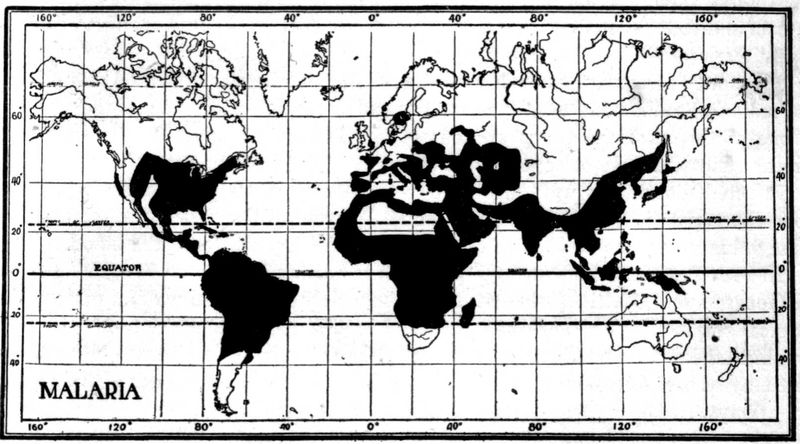


 Question (Case Malaria): A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifically in the Loreto Region near the Amazon River, presents to the clinic with a history of intermittent fevers, shaking chills, and intense sweating, occurring approximately every 48 hours. He also reports significant malaise, headache, and anorexia for the past week. On physical examination, he is febrile with a temperature of 105.2°F (40.7°C), his pulse is rapid at 110 bpm, and his face is flushed. Palpation reveals a significantly enlarged and tender spleen. What is the diagnosis of this patient?

 PROCESSING QUESTION: A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifi...
 Query image provided: Yes

 MULTIMODAL RESULT:

 VARIANT 1b: Model-only - Multimodal
[Model-Only-Multimodal] Answer: Malaria

Clinical Rationale:
The patient's symptoms, including fever, chills, and anorexia, along with the physical examina

In [ ]:
# =========================================================
# Model-only - Multimodal
# =========================================================

# Load query image from Malaria
query_image_path = Path("/kaggle/input/ngoc-extracted/extracted-images/i016.jpg")

query_image = None
if query_image_path.exists():
    query_image = Image.open(query_image_path).convert("RGB")
    print(f" Loaded: {query_image_path.name}")
    display(query_image)
else:
    print(f" Image not found")

# Case Malaria
case_question = (
    "A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifically in the Loreto Region "
    "near the Amazon River, presents to the clinic with a history of intermittent fevers, shaking chills, and intense sweating, "
    "occurring approximately every 48 hours. He also reports significant malaise, headache, and anorexia for the past week. "
    "On physical examination, he is febrile with a temperature of 105.2°F (40.7°C), his pulse is rapid at 110 bpm, and his face is flushed. "
    "Palpation reveals a significantly enlarged and tender spleen. What is the diagnosis of this patient?"
)

print(f"\n Question (Case Malaria): {case_question}")
print("="*70)

# Test all variants
multimodal_results = generate_all_variants(
    question=case_question,
    query_image=query_image,
    top_k_initial=10,
    top_k_final=5
)

# Results with detailed analysis
print("\n MULTIMODAL RESULT:")
print("="*70)

print("\n Model-only - Multimodal")
if multimodal_results.get('model_only_multimodal') and multimodal_results['model_only_multimodal'].get('answer') is not None:
    print(multimodal_results['model_only_multimodal']['answer'][:500] + "...")
else:
    print("⚠️ Skipped (no image provided)")


print("\n"+ "="*70)

 Loaded: i016.jpg


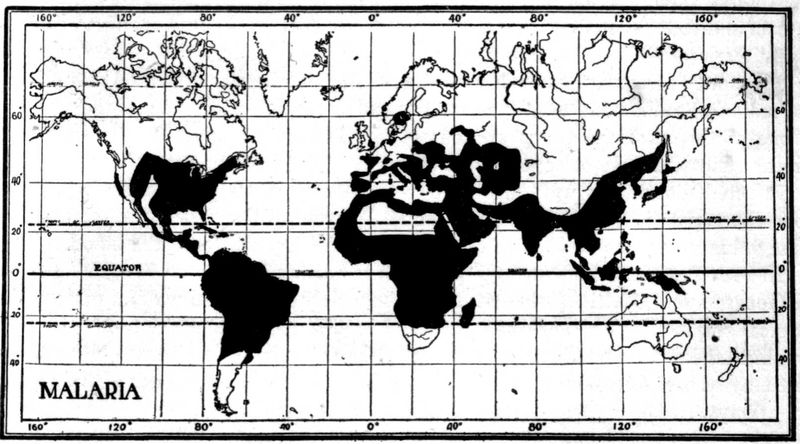


 Question (Case Malaria): A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifically in the Loreto Region near the Amazon River, presents to the clinic with a history of intermittent fevers, shaking chills, and intense sweating, occurring approximately every 48 hours. He also reports significant malaise, headache, and anorexia for the past week. On physical examination, he is febrile with a temperature of 105.2°F (40.7°C), his pulse is rapid at 110 bpm, and his face is flushed. Palpation reveals a significantly enlarged and tender spleen. What is the diagnosis of this patient?

 PROCESSING QUESTION: A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifi...
 Query image provided: Yes

 MULTIMODAL RESULT WITH RETRIEVAL ANALYSIS:

 RAG - Multimodal
[RAG+Multimodal] Answer: Ebola virus disease.

Clinical Rationale:
This patient's symptoms, including fever, chills, and intense sweating, along with 

In [15]:
# =========================================================
# RAG - Multimodal
# =========================================================

# Load query image from Malaria
query_image_path = Path("/kaggle/input/ngoc-extracted/extracted-images/i016.jpg")

query_image = None
if query_image_path.exists():
    query_image = Image.open(query_image_path).convert("RGB")
    print(f" Loaded: {query_image_path.name}")
    display(query_image)
else:
    print(f" Image not found")

# Case Malaria
case_question = (
    "A 35-year-old male of European descent, working as a researcher in the Amazon Basin of Peru, specifically in the Loreto Region "
    "near the Amazon River, presents to the clinic with a history of intermittent fevers, shaking chills, and intense sweating, "
    "occurring approximately every 48 hours. He also reports significant malaise, headache, and anorexia for the past week. "
    "On physical examination, he is febrile with a temperature of 105.2°F (40.7°C), his pulse is rapid at 110 bpm, and his face is flushed. "
    "Palpation reveals a significantly enlarged and tender spleen. What is the diagnosis of this patient?"
)

print(f"\n Question (Case Malaria): {case_question}")
print("="*70)

# Test all variants
multimodal_results = generate_all_variants(
    question=case_question,
    query_image=query_image,
    top_k_initial=10,
    top_k_final=5
)

# Results with detailed analysis
print("\n MULTIMODAL RESULT WITH RETRIEVAL ANALYSIS:")
print("="*70)

print("\n RAG - Multimodal")
if multimodal_results.get('rag_multimodal') and multimodal_results['rag_multimodal'].get('answer') is not None:
    print(multimodal_results['rag_multimodal']['answer'][:300] + "...")
    if multimodal_results['rag_multimodal'].get('docs'):
        print(f"\n Multimodal Re-ranked Contexts ({len(multimodal_results['rag_multimodal']['docs'])}):")
        for i, doc in enumerate(multimodal_results['rag_multimodal']['docs'], 1):
            img_count = len(doc.get('images', []))
            combined_score = doc.get('combined_score', 0)
            original_score = doc.get('similarity_score', 0)
            rerank_score = doc.get('rerank_score', 0)
            retrieval_type = doc.get('retrieval_type', 'unknown')
            
            # Extract Final Diagnosis from document text
            final_diagnosis = "N/A"
            doc_text = doc.get('text', '')
            if 'Final Diagnosis:' in doc_text:
                diag_idx = doc_text.find('Final Diagnosis:')
                diag_text = doc_text[diag_idx + len('Final Diagnosis:'):].strip()
                # Extract just the diagnosis name (before the period or newline)
                final_diagnosis = diag_text.split('\n')[0].split('.')[0].strip()
                if len(final_diagnosis) > 80:
                    final_diagnosis = final_diagnosis[:77] + "..."
            
            print(f"  [{i}] Type: {retrieval_type}")
            print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f} | Images: {img_count}")
            print(f"      Final Diagnosis: {final_diagnosis}")
else:
    print("⚠️ Generation failed or skipped")


print("\n"+ "="*70)

# Step 7: Final RAG + Finetune Generation